In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

For the First step Read the csv file
Use df.head() for to read the first five rows

In [7]:
import pandas as pd
df=pd.read_csv("netflix_users.csv")
df.head()

,User_ID,Name,Age,Country,Subscription_Type,Watch_Time_Hours,Favorite_Genre,Last_Login
0,1,James Martinez,18,France,Premium,80.26,Drama,2024-05-12
1,2,John Miller,23,USA,Premium,321.75,Sci-Fi,2025-02-05
2,3,Emma Davis,60,UK,Basic,35.89,Comedy,2025-01-24
3,4,Emma Miller,44,USA,Premium,261.56,Documentary,2024-03-25
4,5,Jane Smith,68,USA,Standard,909.30,Drama,2025-01-14


Basic Data Understanding
1.df.shape()
2.df.columns()
3.df.info()
4.df.describe()

In [8]:
df.shape

(25000, 8)

info(): used to get the information about file like null values, datatype,memory usage 

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   User_ID            25000 non-null  int64  
 1   Name               25000 non-null  object 
 2   Age                25000 non-null  int64  
 3   Country            25000 non-null  object 
 4   Subscription_Type  25000 non-null  object 
 5   Watch_Time_Hours   25000 non-null  float64
 6   Favorite_Genre     25000 non-null  object 
 7   Last_Login         25000 non-null  object 
dtypes: float64(1), int64(2), object(5)
memory usage: 1.5+ MB


describe(): It shows how your numerical data is spread:
Are values high or low?
Are they consistent or widely spread?

In [10]:
df.describe()

,User_ID,Age,Watch_Time_Hours
count,25000.000000,25000.000000,25000.000000
mean,12500.500000,46.482880,500.468858
std,7217.022701,19.594861,286.381815
min,1.000000,13.000000,0.120000
25%,6250.750000,29.000000,256.567500
50%,12500.500000,46.000000,501.505000
75%,18750.250000,63.000000,745.732500
max,25000.000000,80.000000,999.990000


Checking Missing Values

In [11]:
df.isnull().sum()

User_ID              0
Name                 0
Age                  0
Country              0
Subscription_Type    0
Watch_Time_Hours     0
Favorite_Genre       0
Last_Login           0
dtype: int64

Data Cleaning 

In [15]:
# Remove duplicates
cleaned=df.drop_duplicates(inplace=True)
# Convert Last_Login to datetime
cleaned=df['Last_Login'] = pd.to_datetime(df['Last_Login'])
print(cleaned)

0       2024-05-12
1       2025-02-05
2       2025-01-24
3       2024-03-25
4       2025-01-14
           ...    
24995   2025-01-18
24996   2024-06-29
24997   2024-10-16
24998   2024-08-27
24999   2024-04-12
Name: Last_Login, Length: 25000, dtype: datetime64[ns]


In [21]:
# Ensure correct datatype
df['Last_Login'] = pd.to_datetime(df['Last_Login'])

# Handle missing Age values (optional but recommended)
df['Age'] = df['Age'].fillna(df['Age'].median())

# Create Age Groups
bins = [0, 18, 25, 35, 50, 100]
labels = ['Teen', 'Young Adult', 'Adult', 'Mid Age', 'Senior']

df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels)

# Extract Year & Month
df['Login_Year'] = df['Last_Login'].dt.year
df['Login_Month'] = df['Last_Login'].dt.month

# Display results clearly
print("🔹 Age Group Sample:\n")
print(df['Age_Group'].head())

print("\n🔹 Login Year Sample:\n")
print(df['Login_Year'].head())

print("\n🔹 Login Month Sample:\n")
print(df['Login_Month'].head())

🔹 Age Group Sample:

0           Teen
1    Young Adult
2         Senior
3        Mid Age
4         Senior
Name: Age_Group, dtype: category
Categories (5, object): ['Teen' < 'Young Adult' < 'Adult' < 'Mid Age' < 'Senior']

🔹 Login Year Sample:

0    2024
1    2025
2    2025
3    2024
4    2025
Name: Login_Year, dtype: int32

🔹 Login Month Sample:

0    5
1    2
2    1
3    3
4    1
Name: Login_Month, dtype: int32


In [22]:
print(df['Age_Group'].value_counts())
print(df['Login_Year'].value_counts())
print(df['Login_Month'].value_counts().sort_index())

Age_Group
Senior         10977
Mid Age         5582
Adult           3677
Young Adult     2576
Teen            2188
Name: count, dtype: int64
Login_Year
2024    20370
2025     4630
Name: count, dtype: int64
Login_Month
1     2111
2     1973
3     2110
4     2149
5     2112
6     1998
7     2081
8     2082
9     2074
10    2151
11    2009
12    2150
Name: count, dtype: int64


📊 1. Subscription Distribution

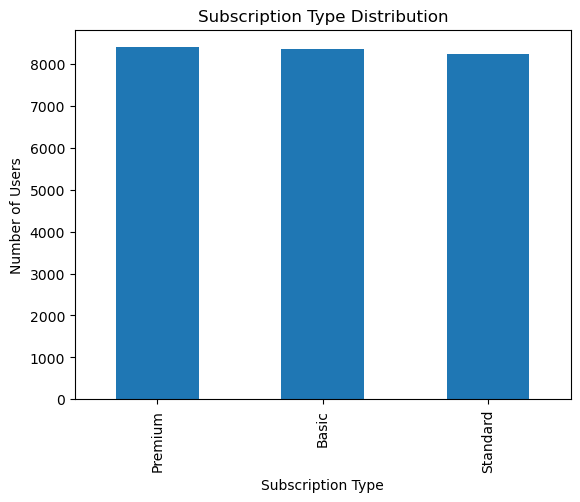

In [5]:
import pandas as pd 
import matplotlib.pyplot as plt
df=pd.read_csv("netflix_users.csv")
plt.figure()
df['Subscription_Type'].value_counts().plot(kind='bar')
plt.title("Subscription Type Distribution")
plt.xlabel("Subscription Type")
plt.ylabel("Number of Users")
plt.show()

📊 2. Age Group vs Subscription

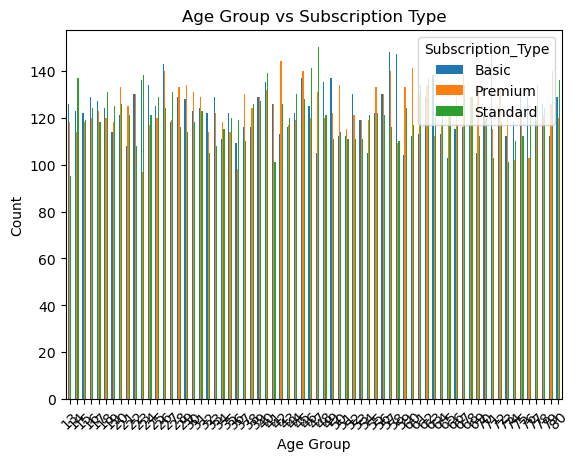

In [7]:
import pandas as pd

age_sub = pd.crosstab(df['Age'], df['Subscription_Type'])

age_sub.plot(kind='bar')
plt.title("Age Group vs Subscription Type")
plt.xlabel("Age Group")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

In [ ]:
import os
os.makedirs("models", exist_ok=True)

In [4]:
# ===============================
# IMPORT LIBRARIES
# ===============================
import pandas as pd
import numpy as np
import pickle
import time
import matplotlib.pyplot as plt
import os

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

# ===============================
# CREATE FOLDER
# ===============================
os.makedirs("models", exist_ok=True)

# ===============================
# LOAD DATA
# ===============================
df = pd.read_csv("netflix_users.csv")

# ===============================
# CLEANING
# ===============================
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)

# ===============================
# FEATURE ENGINEERING
# ===============================
df['Last_Login'] = pd.to_datetime(df['Last_Login'])

df['Login_Year'] = df['Last_Login'].dt.year
df['Login_Month'] = df['Last_Login'].dt.month

bins = [0, 18, 25, 35, 50, 100]
labels = ['Teen', 'Young Adult', 'Adult', 'Mid Age', 'Senior']
df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels)

# ===============================
# FEATURES
# ===============================
features = [
    'Age', 'Country', 'Watch_Time_Hours',
    'Favorite_Genre', 'Login_Year',
    'Login_Month', 'Age_Group'
]

target = 'Subscription_Type'

df = df[features + [target]]

# ===============================
# ENCODING
# ===============================
encoders = {}

for col in df.select_dtypes(include=['object', 'category']).columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

# ===============================
# SPLIT
# ===============================
X = df.drop(target, axis=1)
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ===============================
# SCALING
# ===============================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ===============================
# TRAIN MODELS
# ===============================
models = {
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier()
}

results = {}

print("\n📊 MODEL PERFORMANCE\n")

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    
    results[name] = acc
    print(f"{name}: {acc:.4f}")

# ===============================
# BEST MODEL
# ===============================
best_model_name = max(results, key=results.get)
best_model = models[best_model_name]

print("\n🏆 Best Model:", best_model_name)

# ===============================
# EVALUATION
# ===============================
best_preds = best_model.predict(X_test)

print("\n📄 Classification Report:\n")
print(classification_report(y_test, best_preds))

# ===============================
# SAVE EVERYTHING (ONLY HERE ✅)
# ===============================
pickle.dump(best_model, open("models/netflix_best_model.pkl", "wb"))
pickle.dump(scaler, open("models/netflix_scaler.pkl", "wb"))
pickle.dump(encoders, open("models/netflix_encoders.pkl", "wb"))

print("\n✅ All Models Saved Successfully")

# ===============================
# REAL-TIME SIMULATION
# ===============================
print("\n🔴 Real-Time Prediction Simulation\n")

for _ in range(5):
    sample = X_test[np.random.randint(0, len(X_test))].reshape(1, -1)
    pred = best_model.predict(sample)
    print("Live Prediction:", pred)
    time.sleep(2)


📊 MODEL PERFORMANCE

Random Forest: 0.3308
SVM: 0.3254
Logistic Regression: 0.3286
KNN: 0.3264

🏆 Best Model: Random Forest

📄 Classification Report:

              precision    recall  f1-score   support

           0       0.35      0.34      0.35      1706
           1       0.34      0.35      0.35      1688
           2       0.30      0.30      0.30      1606

    accuracy                           0.33      5000
   macro avg       0.33      0.33      0.33      5000
weighted avg       0.33      0.33      0.33      5000


✅ All Models Saved Successfully

🔴 Real-Time Prediction Simulation

Live Prediction: [2]
Live Prediction: [0]
Live Prediction: [0]
Live Prediction: [1]
Live Prediction: [0]
